# Latent Variable Models (Logistic Regression)

### Foundations of Machine Learning

**Q1.** Please answer the following questions in your own words:

1. Why do we use general linear models/latent variable models/activation functions in analysis? What advantage do they have over linear models?
2. Explain why binary and categorical cross entropy are effective loss functions for fitting logistic regression models.
3. True or false, and explain: Logistic regression is a linear model.
4. True or false, and explain: Logistic regression cannot be used for classification.
5. Does the coefficient in a logistic regression represent the change in the predicted value for a 1 unit change in the feature/covariate/explanatory variable?
6. True or false, and explain: Feature engineering is unnecessary for logistic regression, because it is a nonlinear model.
7. True or false, and explain: Logistic regression is an improvement over the usual linear model (ordinary least squares), and you should always use logistic regression instead.

1. We use general linear models and activation functions to model relationships where their outcomes are not continuous or non-linear. Some advantages of this are that the outputs are better suited for classification and for handling other nonlinear data. 
2. Binary and categorial entropy are effective loss functions for fitting logistic models because they penalize confident but wrong predictions to improve the model and make it better-suited for classification tasks. 
3. True: Logistic regression is linear because it models a linear combination of features, but applies a nonlinear transformation. 
4. False: Log regression is commonly used for classification by transforming probabilities into class labels. 
5. No, it does not represent a change in the predicted probabilities. It represents the change in the log of the outcomes for a one-unit increase in the feature. 
6. False: Feature engineering is important because without it, logistic regression may not capture complex relationships 
7. False: OLS is better for more continuous outcomes.

**Q2.** This is a question about student dropout probability.

The relevant data are in `data.csv` and the file is semicolon-separated.

The relevant variables are:
- `Debtor` - `1` if the student has outstanding debt and `0` otherwise
- `Tuition fees up to date` - `1` if tuition is up to date and `0` otherwise
- `Scholarship holder` - `1` if the student has a scholarship and `0` otherwise
- `Age at enrollment` - student's age when entering the program
- `Curricular units 1st sem (approved)` - number of first-semester courses passed
- `Target` - `Dropout`, `Graduate`, or `Enrolled`

1. Load the data, `data.csv`. Be sure to read it with the correct delimiter. Filter on columns to the variables we'll actually use. Document how you handle any missing values. For parts 2-5, create a binary target where `Dropout` corresponds to dropout and `Graduate` or `Enrolled` corresponds to not dropout.

2. Run a logistic regression of dropout status on `Debtor`, `Tuition fees up to date`, `Scholarship holder`, and `Age at enrollment`. Which variables predict a higher dropout probability, and which predict a lower dropout probability? Does being up to date on tuition seem to reduce dropout risk?

3. Use `.predict_proba` and compute expected dropout probabilities. Make a scatter plot of your predicted dropout probability against `Age at enrollment`, hued by `Tuition fees up to date`. For what ages does being up to date on tuition seem to reduce dropout probability the most? On average, by how much does being up to date on tuition change the predicted probability of dropout?

4. Use `.predict` and compute a confusion matrix for your classifier. What is the accuracy?

5. Compute predicted dropout probabilities with a linear model with the same variables, and predict dropout probabilities. Make a histogram of predicted probabilities for both logistic regression and the linear model. Compare their performance.

5. Based on your above work, which students are the most at-risk of dropping out? What kinds of interventions can you imagine that would help at-risk students stay enrolled?

6. Run a multinomial logistic regression of `Target` on `Debtor`, `Tuition fees up to date`, and `Curricular units 1st sem (approved)`. Use `.predict` to make a hard classification, and compute a confusion matrix. Describe your results. Use `.predict_proba` to predict probabilities instead and look at the values. Does your hard classification predict every class? Do your predicted probabilities predict every class?


In [22]:
#1 
import pandas as pd

df = pd.read_csv("./data/data.csv", sep=";")

df = df[[
    "Debtor",
    "Tuition fees up to date",
    "Scholarship holder",
    "Age at enrollment",
    "Curricular units 1st sem (approved)",
    "Target"
]]

df = df.dropna()

df["dropout"] = (df["Target"] == "Dropout").astype(int)

'''I only kept relevant variables and dropped all missing values. I also created a binary target where the dropout = 1 and graduate/enrolled = 0'''


'I only kept relevant variables and dropped all missing values. I also created a binary target where the dropout = 1 and graduate/enrolled = 0'

In [23]:
#2
from sklearn.linear_model import LogisticRegression
X = df[["Debtor", "Tuition fees up to date", "Scholarship holder", "Age at enrollment"]]
y = df["dropout"]

logit = LogisticRegression(max_iter=1000)
logit.fit(X, y)

print(logit.coef_)
'''Variables with positive coefficients increase the probability of dropout.'''

[[ 0.53062542 -2.55654243 -1.22744152  0.04992541]]


'Variables with positive coefficients increase the probability of dropout.'

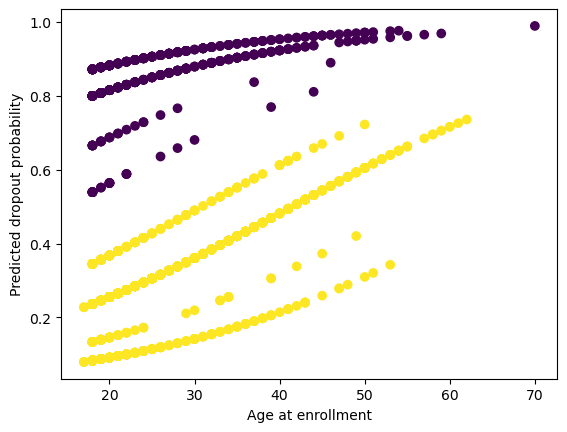

-0.5161819741213389


'Being up to date on tuition reduced the dropout probability while the average chance probability is the value that was printed'

In [24]:
#3
import matplotlib.pyplot as plt
probs = logit.predict_proba(X)[:, 1]

plt.scatter(df["Age at enrollment"], probs, c=df["Tuition fees up to date"])
plt.xlabel("Age at enrollment")
plt.ylabel("Predicted dropout probability")
plt.show()

X0 = X.copy()
X0["Tuition fees up to date"] = 0
X1 = X.copy()
X1["Tuition fees up to date"] = 1

p0 = logit.predict_proba(X0)[:, 1]
p1 = logit.predict_proba(X1)[:, 1]
print((p1 - p0).mean())

'''Being up to date on tuition reduced the dropout probability while the average chance probability is the value that was printed'''

In [25]:
#4
from sklearn.metrics import confusion_matrix, accuracy_score

pred = logit.predict(X)
print(confusion_matrix(y, pred))
print(accuracy_score(y, pred))
'''This matrix shows classification results and the accuracy is the proportion correctly classified.'''

[[2841  162]
 [ 891  530]]
0.7619801084990958


'This matrix shows classification results and the accuracy is the proportion correctly classified.'

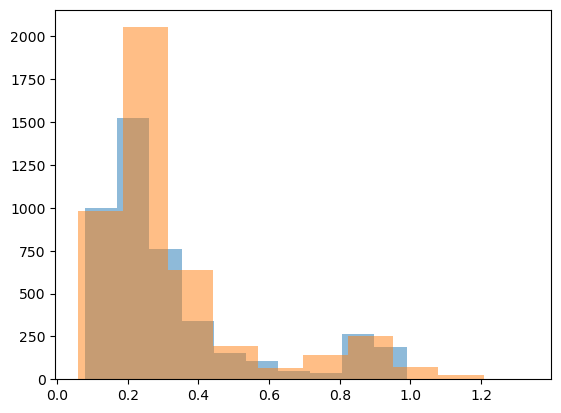

'The log regression producues probailities between 0 and 1 '

In [26]:
#5 
from sklearn.linear_model import LinearRegression

lin = LinearRegression()
lin.fit(X, y)

lin_pred = lin.predict(X)
log_pred = logit.predict_proba(X)[:, 1]

import matplotlib.pyplot as plt
plt.hist(log_pred, alpha=0.5)
plt.hist(lin_pred, alpha=0.5)
plt.show()

'''The log regression producues probailities between 0 and 1 '''

In [27]:
#5 
'''Students with a higher predicted dropout probability are most at risk. Some forms of intervention could be financial aid or academic tutoring or intervention'''

'Students with a higher predicted dropout probability are most at risk. Some forms of intervention could be financial aid or academic tutoring or intervention'

In [28]:
#6 
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix

X2 = df[[
    "Debtor",
    "Tuition fees up to date",
    "Curricular units 1st sem (approved)"
]]
y2 = df["Target"]

multi = LogisticRegression(multi_class="multinomial", max_iter=1000)
multi.fit(X2, y2)

pred2 = multi.predict(X2)
print(confusion_matrix(y2, pred2))

print(multi.predict_proba(X2)[:5])

'''The confusion matrix shows the classification results for the three classes.'''

[[1054    0  367]
 [ 280    0  514]
 [ 146    0 2063]]
[[0.68054695 0.21046429 0.10898876]
 [0.69541412 0.1460432  0.15854268]
 [0.95298821 0.04119918 0.00581261]
 [0.11780804 0.1769832  0.70520876]
 [0.18422683 0.21266883 0.60310434]]


/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


'The confusion matrix shows the classification results for the three classes.'

**Q3.** This is a question about 10-year survival rate for cirrhosis of the liver.

The relevant data are:
- `Bilirubin` - A liver byproduct produced when red blood cells break down
- `Edema` - Swelling in limbs; `N` for none, `S` for edema resolvable with diuretics, `Y` for edema despite dirutics 
- `Drug` - D-penicillamine, or placebo
- `Stage` - current state of disease, from 1 to 4
- `Status` - `C` or `CL` corresponds to alive, and `D` corresponds to dead

1. Load the data, `cirrhosis.csv`. Filter on columns to the variables we'll actually use. Document how you handle any missing values.

2. Run a logistic regression of `Status` on `Edema`, `Drug`, and `Bilirubin`. Does the drug improve survival probability? Does higher or lower bilirubin predict a higher or lower survival rate? How does survival rate vary with edema?

3. Use `.predict_proba` and compute expected surivival probabilities. Make a scatter plot of your predicted survival probability against `Bilirubin`, hued by `Drug`. For what values of `Bilirubin` does the drug seem to increase patient survival rate? On average, by how much do patients who take the drug increase their probability of survival?

4. Use `.predict` and compute a confusion matrix for your classifier. What is the accuracy?

5. Compute predicted survival probabilities with a linear model with the same variables, and predict survival probabilties. Make a histogram of predictive probabilties for both logistic regression and the linear model. Compare their performance.

6. Run a logistic regression of `Stage` on `Edema` and `Bilirubin`. Use `.predict` to make a hard classification, and compute a confusion matrix. Describe your results. Use `.predict_proba` to predict probabilities instead and look at the values. Does your hard classification predict every class? Do your predicted probabilities predict every class? 

In [29]:
#1 
import pandas as pd
df = pd.read_csv("./data/cirrhosis.csv")
df = df[["Bilirubin", "Edema", "Drug", "Stage", "Status"]]
df = df.dropna()
'''I loaded the data and kept only the relevant columns.'''

'I loaded the data and kept only the relevant columns.'

In [30]:
#2
from sklearn.linear_model import LogisticRegression

df["survive"] = df["Status"].isin(["C", "CL"]).astype(int)
X = pd.get_dummies(df[["Edema", "Drug"]], drop_first=True)
X["Bilirubin"] = df["Bilirubin"]

y = df["survive"]
logit = LogisticRegression(max_iter=1000)
logit.fit(X, y)
coef_df = pd.DataFrame({
    "feature": X.columns,
    "coefficient": logit.coef_[0]
})
print(coef_df)
'''If the drug coefficient is positive, the drug improves the survival chances. If the bilirubin coefficient is negative, there is a higher rate of survival. The edema coefficient shows how the survival rate changes relative to the edema category.'''

        feature  coefficient
0       Edema_S    -0.450677
1       Edema_Y    -1.611049
2  Drug_Placebo     0.231225
3     Bilirubin    -0.351424


'If the drug coefficient is positive, the drug improves the survival chances. If the bilirubin coefficient is negative, there is a higher rate of survival. The edema coefficient shows how the survival rate changes relative to the edema category.'

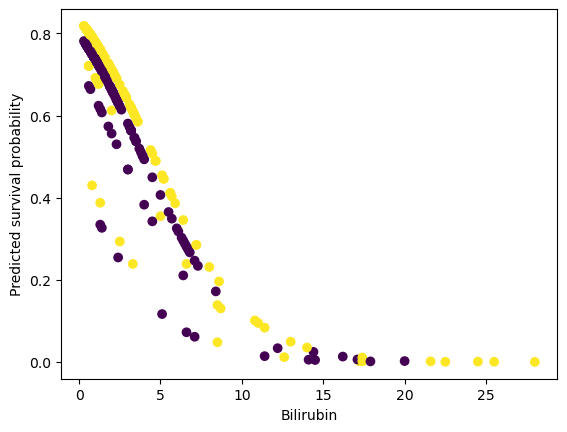

0.04242663943164016


'The drug appears to increase the survival where the predicted probabilities are higher for patients taking the drug at the same bilirubin levels. The average change in the survival probability is the value that was printed.'

In [31]:
#3
import matplotlib.pyplot as plt

probs = logit.predict_proba(X)[:, 1]
plt.scatter(df["Bilirubin"], probs, c=pd.factorize(df["Drug"])[0])
plt.xlabel("Bilirubin")
plt.ylabel("Predicted survival probability")
plt.show()

X0 = X.copy()
for col in X.columns:
    if "Drug" in col:
        X0[col] = 0

X1 = X.copy()
for col in X.columns:
    if "Drug" in col:
        X1[col] = 1

p0 = logit.predict_proba(X0)[:, 1]
p1 = logit.predict_proba(X1)[:, 1]

print((p1 - p0).mean())
'''The drug appears to increase the survival where the predicted probabilities are higher for patients taking the drug at the same bilirubin levels. The average change in the survival probability is the value that was printed.'''

In [32]:
#4 
from sklearn.metrics import confusion_matrix, accuracy_score

pred = logit.predict(X)

print(confusion_matrix(y, pred))
print(accuracy_score(y, pred))
'''The confusion matrix shows the number of correct and incorrect classifications. The accuracy is the proportion of correctly classified samples.'''

[[ 59  66]
 [ 16 171]]
0.7371794871794872


'The confusion matrix shows the number of correct and incorrect classifications. The accuracy is the proportion of correctly classified samples.'

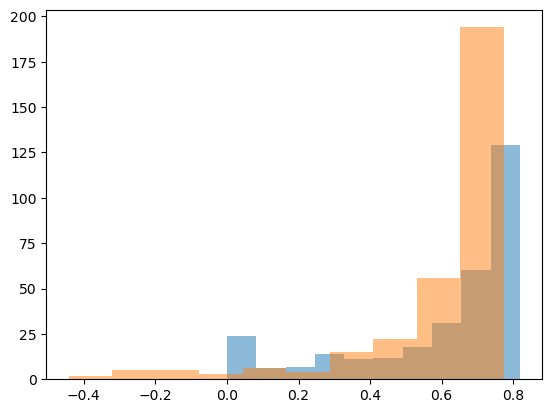

'The logistic regression produces probabilities between 0 and 1 while the linear regression can produce values outside this range. The log regression is more appropriate for this binary classification problem.'

In [33]:
#5 
from sklearn.linear_model import LinearRegression

lin = LinearRegression()
lin.fit(X, y)

lin_pred = lin.predict(X)
log_pred = logit.predict_proba(X)[:, 1]

plt.hist(log_pred, alpha=0.5)
plt.hist(lin_pred, alpha=0.5)
plt.show()

'''The logistic regression produces probabilities between 0 and 1 while the linear regression can produce values outside this range. The log regression is more appropriate for this binary classification problem.'''

In [34]:
#6 
X2 = pd.get_dummies(df[["Edema"]], drop_first=True)
X2["Bilirubin"] = df["Bilirubin"]
y2 = df["Stage"]
multi = LogisticRegression(max_iter=1000)
multi.fit(X2, y2)
pred2 = multi.predict(X2)
print(confusion_matrix(y2, pred2))

print(multi.predict_proba(X2)[:5])

'''The confusion matrix shows how well the model classifies the disease stages. The predicted probabilities show the model's confidence in each stage for the first 5 samples.'''

[[  0   0  16   0]
 [  0   0  63   4]
 [  0   0 105  15]
 [  0   0  79  30]]
[[1.28550372e-05 3.25351316e-02 1.43611431e-01 8.23840583e-01]
 [7.23937578e-02 2.51555267e-01 3.97519699e-01 2.78531276e-01]
 [2.92626485e-02 1.81530850e-01 3.95694470e-01 3.93512032e-01]
 [2.32719781e-02 1.76777228e-01 3.97216502e-01 4.02734292e-01]
 [2.02038998e-02 2.24965391e-01 4.23342268e-01 3.31488440e-01]]


"The confusion matrix shows how well the model classifies the disease stages. The predicted probabilities show the model's confidence in each stage for the first 5 samples."

**Q4.** What are the coefficients of a logistic regression? How do you interpret their values?

1. For your linear model, your predictions are:
$$
\hat{y} = b \cdot x = b_0 + \sum_{k=1}^K b_k x_{k}
$$
What is the derivative of the prediction with respect to the $k$-th feature? For a 1 unit change in your feature, by how much does the prediction change?

2. For the logistic model, your predictions are:
$$
\hat{p}_i = \dfrac{e^{b \cdot x}}{1+e^{b \cdot x}}
$$
What is the derivative of the prediction with respect to the $k$-th feature? As $x$ changes, does your answer change? How is it similar or different from your answer for part 1? Hint: It turns out that
$$
\frac{ \partial }{ \partial L} \dfrac{e^{L}}{1+e^{L}}= \frac{e^{L}}{(1+e^{L})^2} = \frac{e^{L}}{1+e^{L}}\frac{1}{1+e^{L}} = \frac{e^{L}}{1+e^{L}} \left( 1 - \frac{e^{L}}{1+e^{L}} \right),
$$
and use the chain rule( $D_x f(g(x)) = f'(g(x))g'(x)$). For what values of $\hat{p}$ is the coefficient itself (...times 4) roughly a good estimate of how a change in $x_k$ affects the prediction?

3. Alternatively, we can transform the prediction like this:

\begin{alignat*}{2}
\hat{p} &=& \frac{ e^{b \cdot x} }{1+e^{b \cdot x}} \\
\hat{p}(1+e^{b \cdot x}) &=& e^{b \cdot x} \\
\hat{p} &=& (1-\hat{p}) e^{b \cdot x} \\
\log \left( \frac{\hat{p}}{1-\hat{p}} \right) &=& b \cdot x \\
\end{alignat*}

The left-hand side of the above expression is called the **log odds ratio**, and the right-hand side is the latent variable. How does a one unit change in $x_k$ affect the log odds ratio? 

1. The derivative is bk. This means a one-unit increase in xk changes the prediction by bk. It does not depend on the values of x.
2. The derivative is bk * phat(1 - phat). This means the effect of xk depends on the value of phat. The effect is not constant like the linear model. 
3. The derivative of log(phat/ 1 - phat) is bk. This means that a one-unit increase in xk increases the log odds ratio by bk.  